<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Table of Contents:

- [Imports](#imports)
- [Architectural and Performance Decisions](#architectual-and-performance-decisions)
- [Complex Network Feature Engineering](#complex-network-feature-engineering)
- [Initial Data Dictionary](#initial-data-dictionary)
- [Statistical and Associative Data Exploration](#statistical-and-associative-data-exploration)
- [Final Data Dictionary](#final-data-dictionary)

</div>

### ORIENTATION:

This file is intended to make decisions regarding the implementation of mathematic Complex Network ideas as well as their implementation into the 'NF-UQ-NIDS-v2 Network Intrusion Detection Dataset' and exploration of these newly engineered features.  Given the nature of complex networks reliance on matrix manipulation, analysis of graph generation time and matrix computation between NetworkX and iGraph will be the fundamental determining factors for expediency.

---

### IMPORTANT NOTE:

The nature of the dataset produces a **NON-COMPLETE** graph **WITHOUT** timestamps; The overall graph largely consists of star graphs where multiple nodes connect to the same destination node.  For this reason, to create a complete graph, we will have to analyze each star graph independently and will attempt to create a directed and weighted graph to derive the most information as possible since geographic information is generally non-existent in the dataset.  This fundamentally will change how we derive matricies, eigenvalues/eigenvectors, laplacians, and walks/PageRank.

---

### SUMMARY:

- Architectural and Performance Decisions
    - We will create a directed and weighted graph by:
        1. Group `ipv4_src_addr`
        2. Group `ipv4_dst_addr`
        3. Group `target` 
        4. Engineer continuous feature `edge_weight` (based on `explore_normal_data.ipynb`'s findings) with `in_bytes, out_bytes, duration_in`
        5. Engineer binary features `is_star_graph, is_chain_graph, is_bridge_link` using diameter for the first two and iGraph's `bridges()` function
        6. Drop all other information as they are unnecessary for complex network feature engineering at this point
    - NetworkX is faster at graph generation and iGraph is faster at matrix manipulation.  For this reason, iGraph will be used for complex network manipulation and feature engineering.
- Complex Network Feature Engineering
    - Filtered original dataset down to grouped source then destination ips and derived features denoted in the *Architectural and Performance Decisions* section of this notebook
    - Removed 0.0.0.0 IPs since they don't provide any useful insight (Noise)
    - Engineered:
        - `graph_id`
        - `baseline_edge_weight_ratio`
        - `baseline_edge_weight_zscore`
        - `eigen_1`
        - `eigen_2`
        - `v1_src`
        - `v2_src`
        - `src_pagerank`
        - `dst_pagerank`
        - `convergence_steps`
        - `spectral_gap`
- Initial Data Dictionary
    - The dataset used is the `clean_complex.parquet` which is a grouped version and altered version of `clean_short.parquet` specifically for complex network purposes
    - Rows: 241,361
    - Columns: 16
    - Target: `attack` (21 Unique tags, distribution visualized below data dictionary)
    - Note that the data is now **highly** imbalanced with over 99% entries being `benign` as opposed to the original 33%.  This is likely because of grouping, but may prove an even stronger association of complex network capabilities during model evaluation if the complex network version performs better
- Statistical and Associative Data Exploration
- Final Data Dictionary


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Imports

- [Back to Table of Contents](#table-of-contents)

</div>

In [1]:
# Largely for re-usable visuals, statistics, and helper functions
import explore_normal_data as eND

# Necessary for Complex Network related functions
import explore_complex_networks as eCN

import numpy as np
import pandas as pd
import networkx as nx
import igraph as ig
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Architectural and Performance Decisions

- [Back to Table of Contents](#table-of-contents)

</div>

##### SUMMARY

- We will create a directed and weighted graph by:
    1. Group `ipv4_src_addr`
    2. Group `ipv4_dst_addr`
    3. Group `target` 
    4. Engineer continuous feature `edge_weight` (based on `explore_normal_data.ipynb`'s findings) with `in_bytes, out_bytes, duration_in`
    5. Engineer binary features `is_star_graph, is_chain_graph, is_bridge_link` using diameter for the first two and iGraph's `bridges()` function
    6. Drop all other information as they are unnecessary for complex network feature engineering at this point
- NetworkX is faster at graph generation and iGraph is faster at matrix manipulation.  For this reason, iGraph will be used for complex network manipulation and feature engineering.

---

##### Dataset Takeaways

- Geometric Description
    - Is disconnected
    - Generally made up of star graphs, but there are more connected and longer paths
    - There exists benign connecting to benign/malicious nodes and malicious connecting to malicious
- Because of the above, we will assign a `graph_id` to every entry to denote what entry belongs to which **COMPLETED GRAPH** so that complex network implementation is cleaner
- Additionally, because star graphs makeup the general structure of most, we will direct and weight edges to embed the most information as possible between node interactions since geography doesn't have a whole lot to offer at first glance.  From the `explore_normal_data.ipynb`, we will weight the edges by aggregating `in_bytes, out_bytes, duration_in` and direct the edges simply with `ipv4_src_addr` and `ipv4_dst_addr`.  To catch any repeat connections, we will group first by the `ipv4_src_addr`, then group by the `ipv4_dst_addr`, then by `target` to catch repeat connections that were benign but malicious in another instance
- From this grouping logic, we will be reducing the entries by grouping the source then the destination ips.  Additionally, we will be engineering a new continuous feature `edge_weight` where all other features are dropped as they are useless in this case
- In terms of this basic geography of the network, we will engineer three binary features for potential ML/NN training and any standalone node (diam=1) will be removed:
    - `is_star_graph` (0,1)
    - `is_chain_graph` (0,1)
    - `is_bridge_link` (0,1)

---

##### iGraph vs. NetworkX

- Timing Comparisons
    - iGraph Faster:
        - Adj Matrix Generation
        - Matrix Multiplication Generation
    - NetworkX Faster:
        - Graph Generation
        

In [2]:
# Load in the dataset
df = pd.read_parquet('datasets/clean_short.parquet')

Graph Status: Not Connected


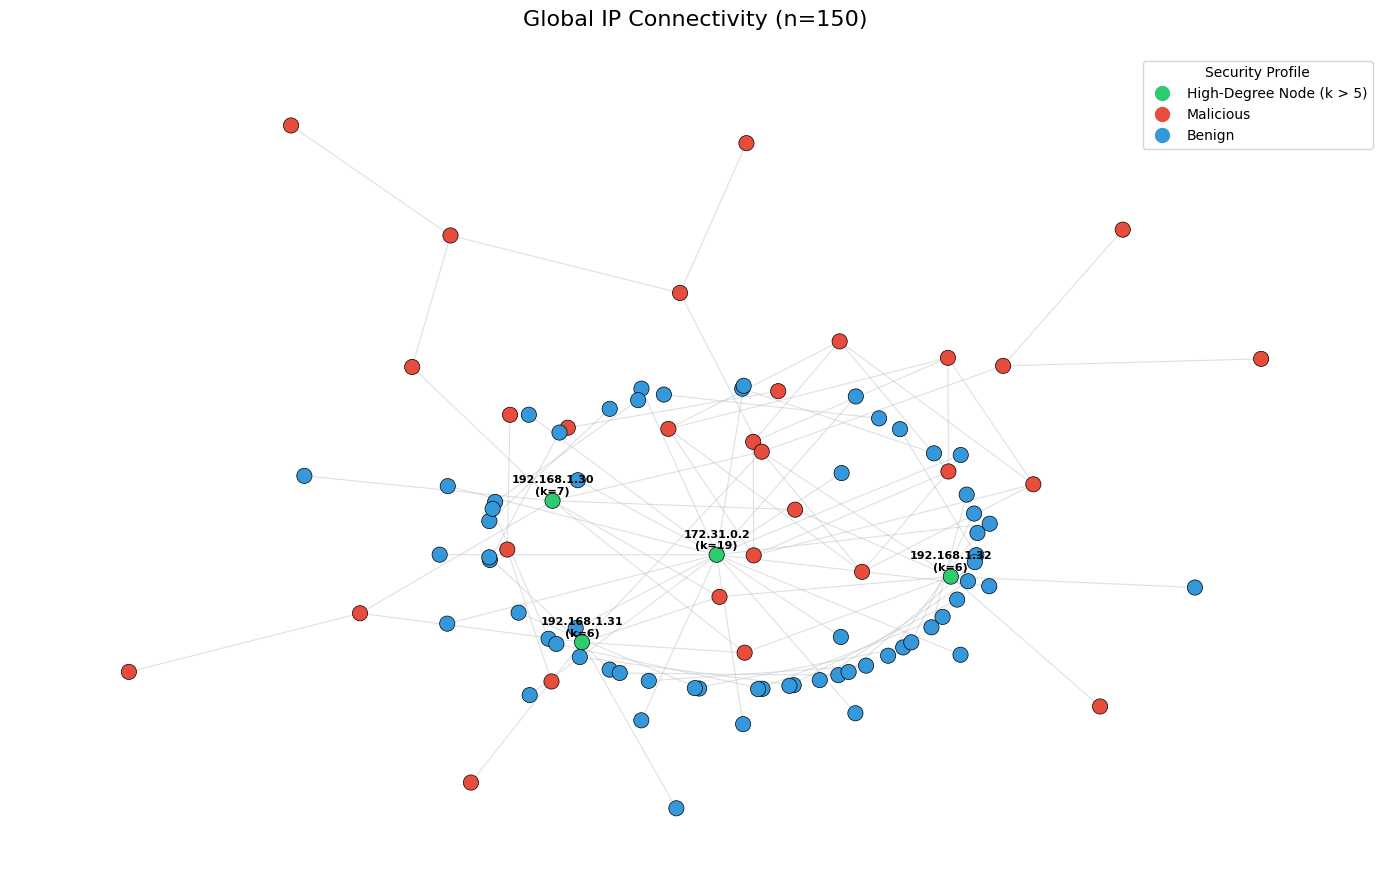

In [3]:
# Visualize the original dataset graph
eCN.vis_original_overall_graph(df)

**Key Takeaway:** The graph is not connected, thus we will need to try and group all the connected graphs in order to properly apply complex network ideology

---

Verified Topology: Star (Diam=2)


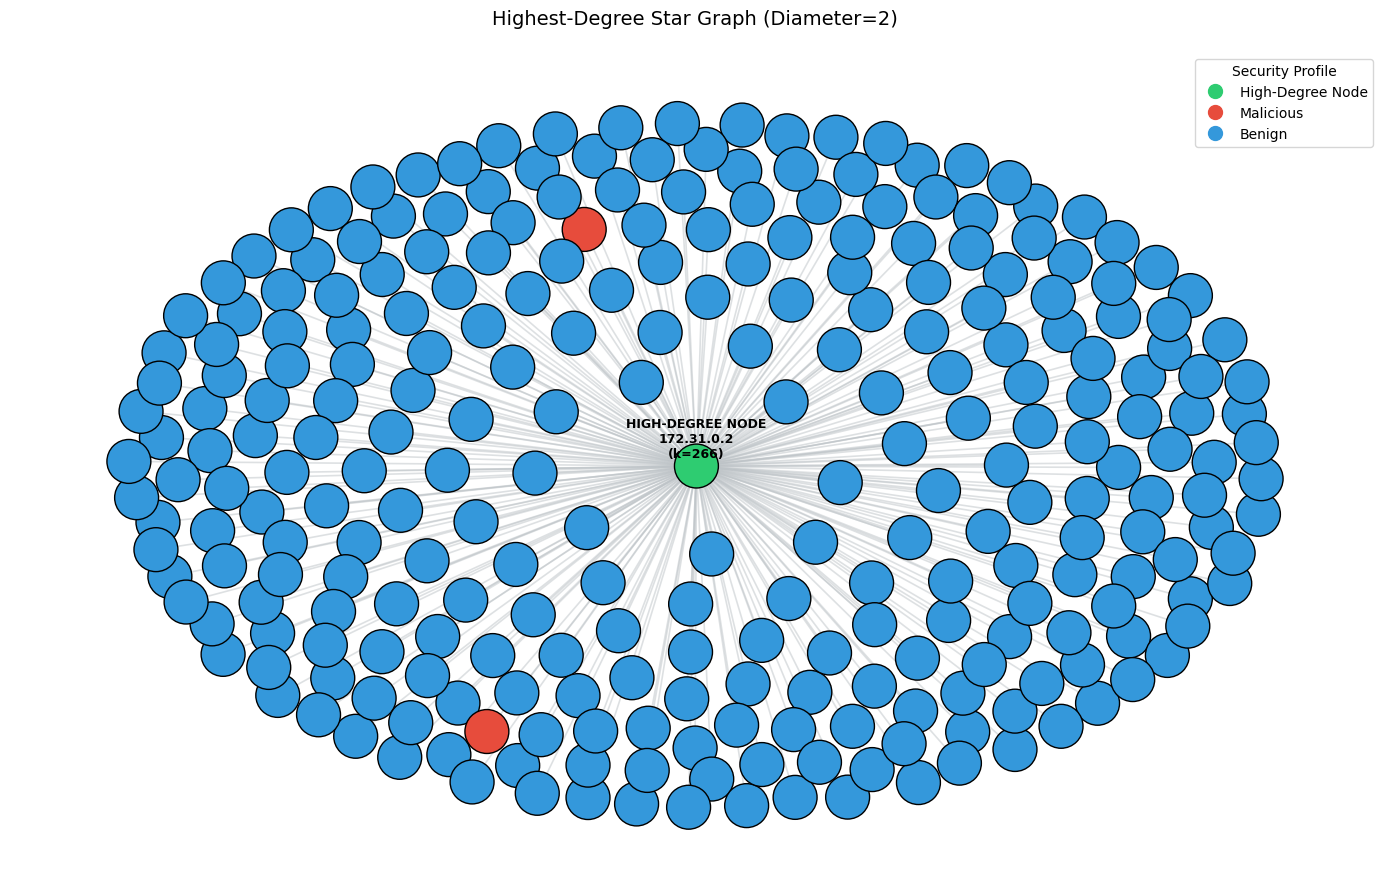

In [4]:
# Visualize the highest-degree star graph
eCN.vis_original_star_graph(df)

**Key Takeaway:** Many of the complete graphs are star graphs, thus we need to determine something about the edge that may deliniate between a benign and malicious connection.  Thus we will create a directed and weighted graph using `in_bytes, out_bytes, duration_in`

---

========== START GRAPH GENERATION COMPARISON ==========


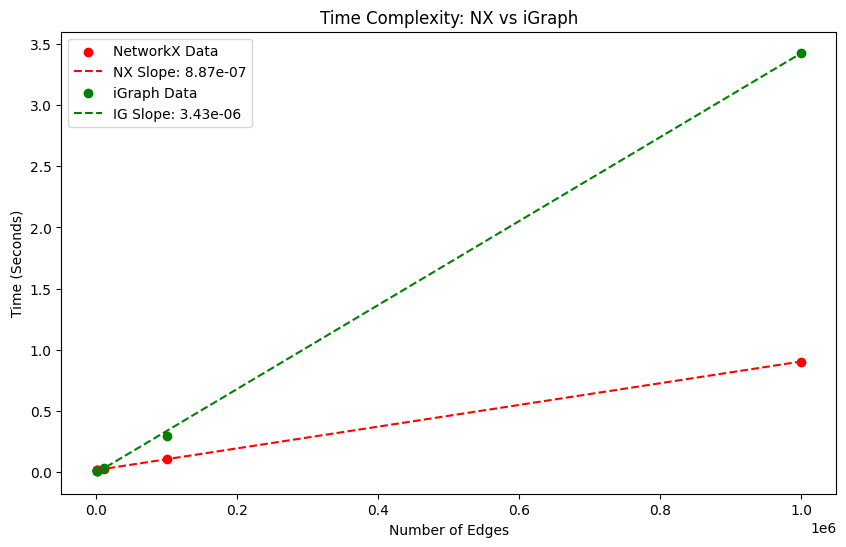

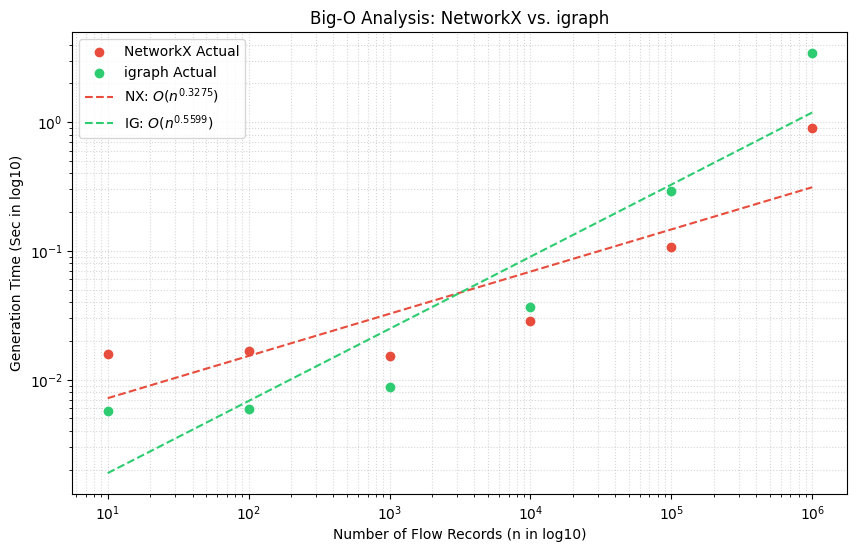

========== START ADJACENCY MATRIX GENERATION COMPARISON ==========


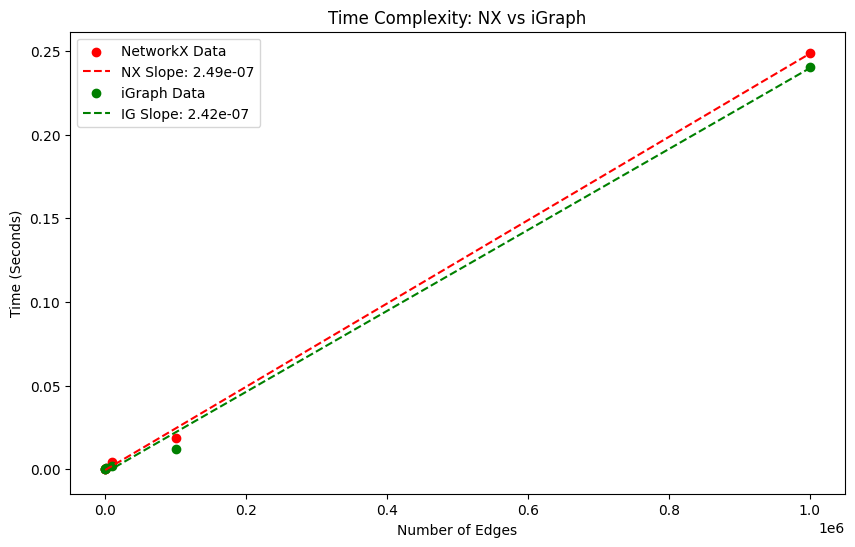

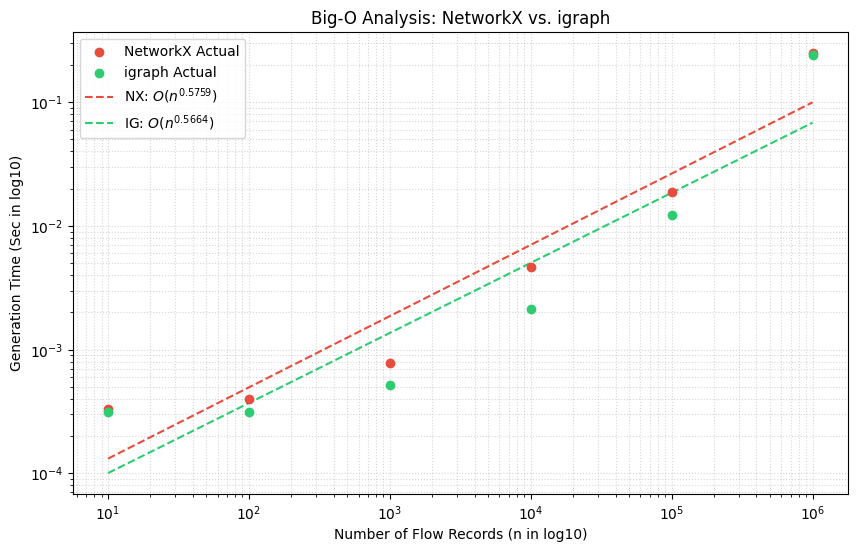

========== START MATRIX MULTIPLICATION GENERATION COMPARISON ==========


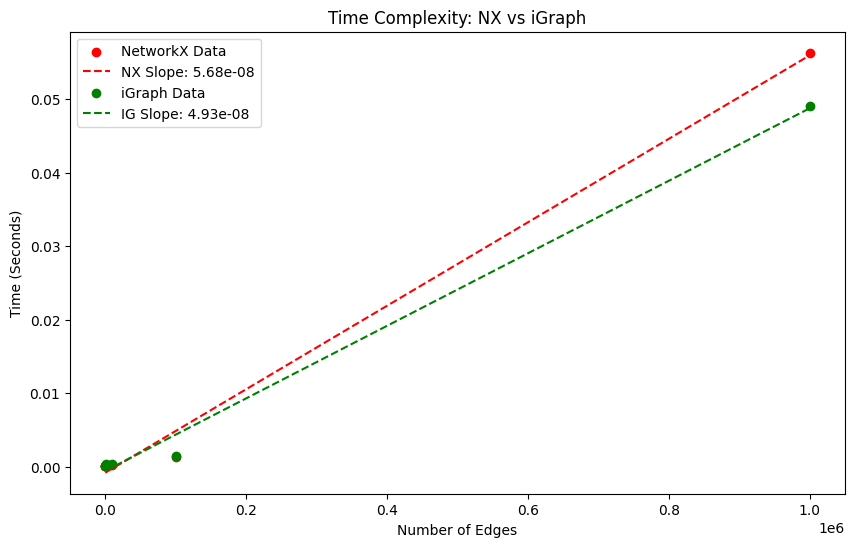

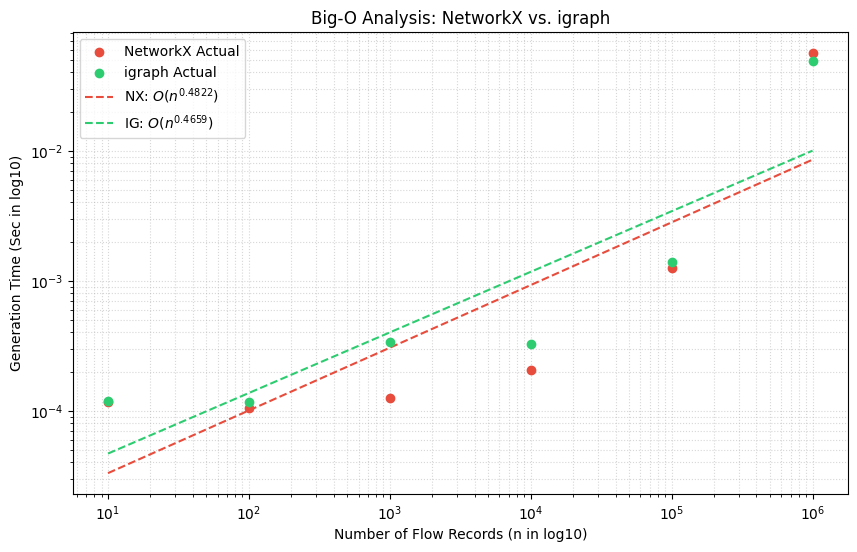

In [5]:
# Visualize graph, adjacency matrix, and matrix multiplication generation timings
eCN.batch_generate_timing(df)

**Key Takeaway:** iGraph seems to be overall superior with computation which is the majority of complex network feature engineering, so we will use iGraph for this reason

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Complex Network Feature Engineering

- [Back to Table of Contents](#table-of-contents)

</div>

### SUMMARY

- Filtered original dataset down to grouped source then destination ips and derived features denoted in the *Architectural and Performance Decisions* section of this notebook
- Removed 0.0.0.0 IPs since they don't provide any useful insight (Noise)
- Engineered:
    - `graph_id`
    - `baseline_edge_weight_ratio`
    - `baseline_edge_weight_zscore`
    - `eigen_1`
    - `eigen_2`
    - `v1_src`
    - `v2_src`
    - `src_pagerank`
    - `dst_pagerank`
    - `convergence_steps`
    - `spectral_gap`

In [3]:
# Initially reduce the dataset from above specifications
initial_reduced_df = eCN.generate_reduced_graph_df(df)

datasets/initial_complex.parquet not detected. Attempting to create datasets/initial_complex.parquet...
Successfully created datasets/initial_complex.parquet!


---

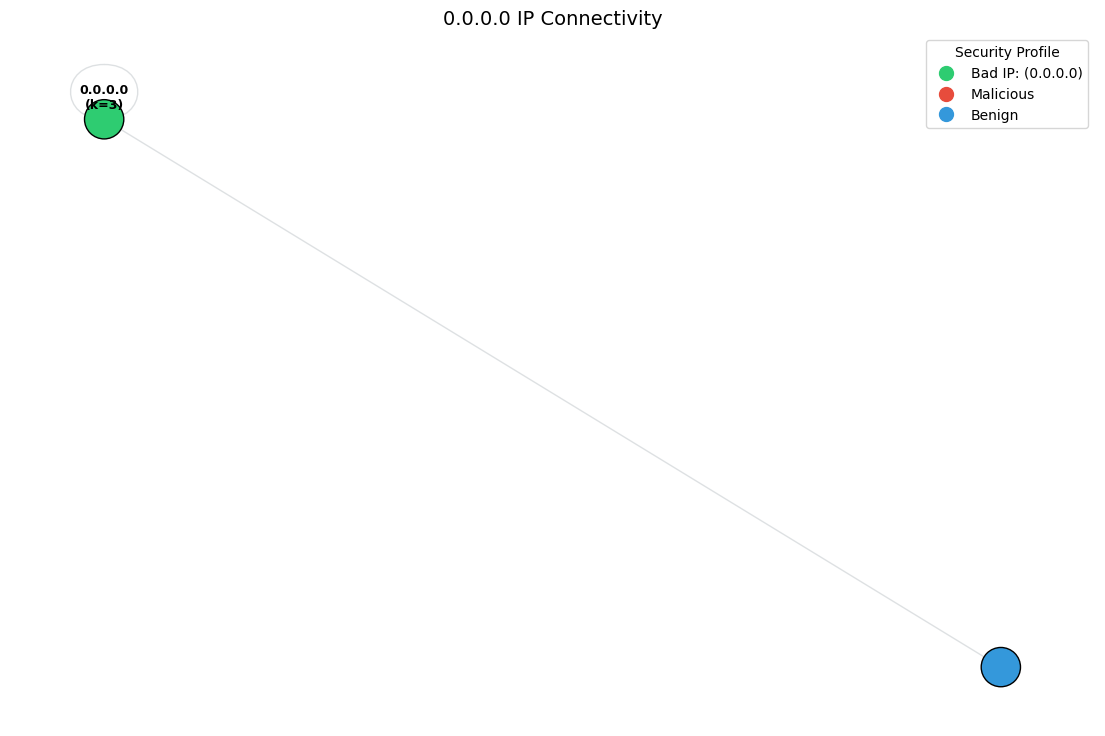

In [4]:
# Visualize 0.0.0.0 graph to determine its significance
eCN.vis_bad_ips(initial_reduced_df)

In [3]:
# Remove 0.0.0.0 IPs
initial_reduced_df = eCN.remove_bad_ips(initial_reduced_df)

Removed 2 rows containing 0.0.0.0.


**Key Takeaway:** 0.0.0.0 IPs will be removed since they hold nothing of importance

---

##### Engineer `graph_id`

In [4]:
# Create the graph IDs for every entry
initial_reduced_df = eCN.generate_graph_ids(initial_reduced_df)

---

##### Engineer `baseline_edge_weight_ratio` and `baseline_edge_weight_zscore` from `attack==benign` as a baseline

In [5]:
# Create the edge_weight ratio/zscore based on the benign entries as the baseline
initial_reduced_df = eCN.generate_intensity_and_zscore(initial_reduced_df)

---

##### Engineer `eigen_1, eigen_2, v1_src, v2_src, src_pagerank, dst_pagerank, convergence_steps, spectral_gap`

In [6]:
# Get the complex network information
initial_reduced_df = eCN.generate_complex_network_information(initial_reduced_df)

---

##### Create `datasets/clean_complex.parquet`

In [7]:
# Create cleaned dataset
initial_reduced_df.to_parquet('datasets/clean_complex.parquet')

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Initial Data Dictionary

- [Back to Table of Contents](#table-of-contents)

</div>

In [9]:
# Read in the dataset
clean_df = pd.read_parquet('datasets/clean_complex.parquet')

The dataset used is the `clean_complex.parquet` which is a grouped version and altered version of `clean_short.parquet` specifically for complex network purposes

- Rows: 241,361
- Columns: 18
- Target: `attack` (21 Unique tags, distribution visualized below data dictionary)

| Feature Name | Dtype | Example | Description |
| :--- | :--- | :--- | :--- |
| **source_ip** | `str` | 0.147.57.10 | Unique identifier for the originating network node. |
| **destination_ip** | `str` | 192.168.1.194 | Unique identifier for the receiving network node. |
| **edge_weight** | `float64` | 840.0 | Raw magnitude of traffic weighting the connection. |
| **is_star_graph** | `int64` | 0, 1 | Boolean flag: 1 if the flow belongs to a hub-and-spoke topology. |
| **is_chain_graph** | `int64` | 1, 0 | Boolean flag: 1 if the flow is part of a sequential multi-hop path. |
| **is_bridge_link** | `int64` | 1, 0 | Boolean flag: 1 if this edge connects two distinct graph islands. |
| **attack** | `str` | benign, ddos | Ground-truth label for security classification. |
| **graph_id** | `int64` | 0, 1, 2 | Unique identifier for the discrete graph island. |
| **baseline_edge_weight_ratio** | `float64` | 0.024786 | Intensity ratio relative to benign topology averages. |
| **baseline_edge_weight_zscore** | `float64` | -0.019630 | Statistical deviation of flow weight from the benign mean. |
| **eigen_1** | `float64` | 654558925.7 | Principal eigenvalue; total structural energy/traffic mass. |
| **eigen_2** | `float64` | 652123263.7 | Second eigenvalue; indicates secondary clusters or hubs. |
| **v1_src** | `float64` | 8.57e-19 | Source component in the first eigenvector (energy hierarchy). |
| **v2_src** | `float64` | 4.45e-19 | Source component in the second eigenvector (cluster role). |
| **src_pagerank** | `float64` | 0.009910 | Influence score identifying source popularity in the graph. |
| **dst_pagerank** | `float64` | 0.003442 | Influence score identifying destination IP as a traffic sink. |
| **convergence_steps** | `float64` | 56077.0 | Iteration count for spectral stability; proxy for graph diameter. |
| **spectral_gap** | `float64` | 2435661.9 | Absolute difference between eigenvalues; measures centralization. |

/Users/manupfool/Desktop/University_of_Denver/inprogress_courses/COMP3703/final/explore_normal_data.py:468: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.values, y=labels, palette='viridis')


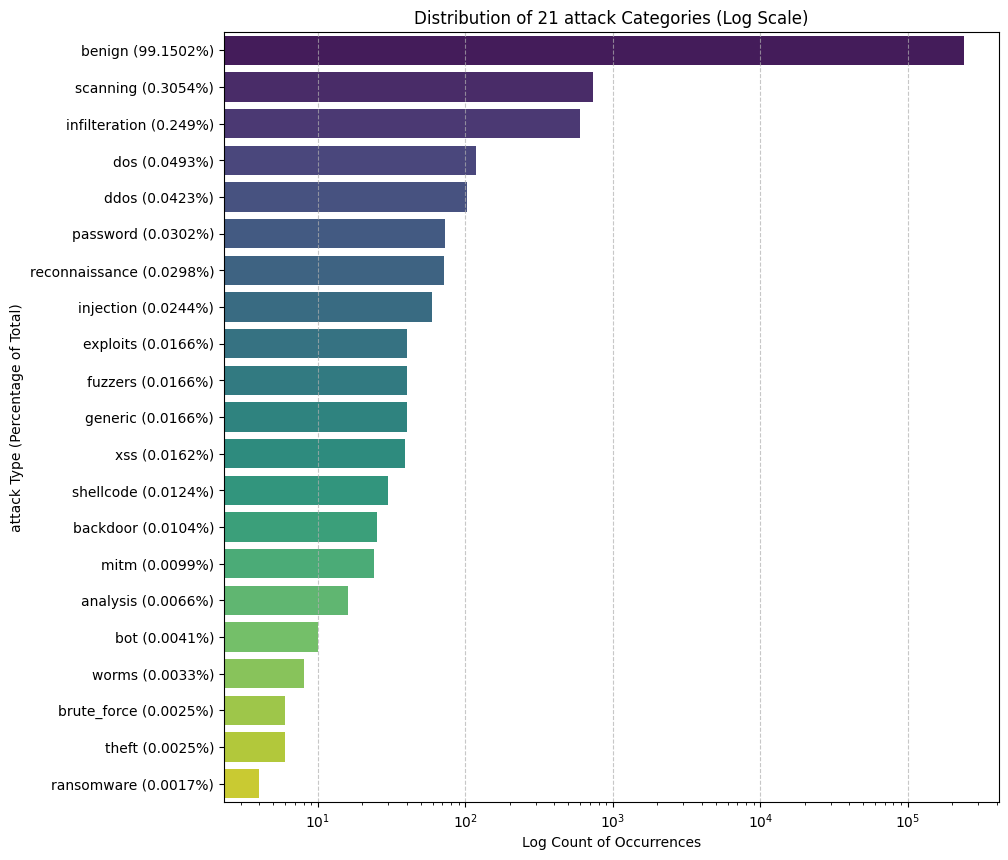

In [19]:
# Visualize target distribution
eND.vis_target_distribution(clean_df)

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Statistical and Associative Data Exploration

- [Back to Table of Contents](#table-of-contents)

</div>

### SUMMARY:

- Initial Removal of Columns For Analysis
    - Assumption of data poisoning
        - source_ip
        - destination_ip
    - Target Variable
        - attack
- Analysis findings for every feature
    - edge_weight // 
    - is_star_graph // 
    - is_chain_graph // 
    - is_bridge_link // 
    - graph_id // 
    - baseline_edge_weight_ratio //
    - baseline_edge_weight_zscore // 
    - eigen_1 // 
    - eigen_2 // 
    - v1_src //
    - v2_src //
    - src_pagerank // 
    - dst_pagerank // 
    - convergence_steps // 
    - spectral_gap // 
- Post Removal of Columns

---
##### Explore edge_weight

- [Back to Table of Contents](#table-of-contents)

VERDICT: 

MISC: 
- 

edge_weight IS statistically significant with attack!
Statistic: 1351.4785
P-Val: 0.0000
P-Threshold: 0.0500



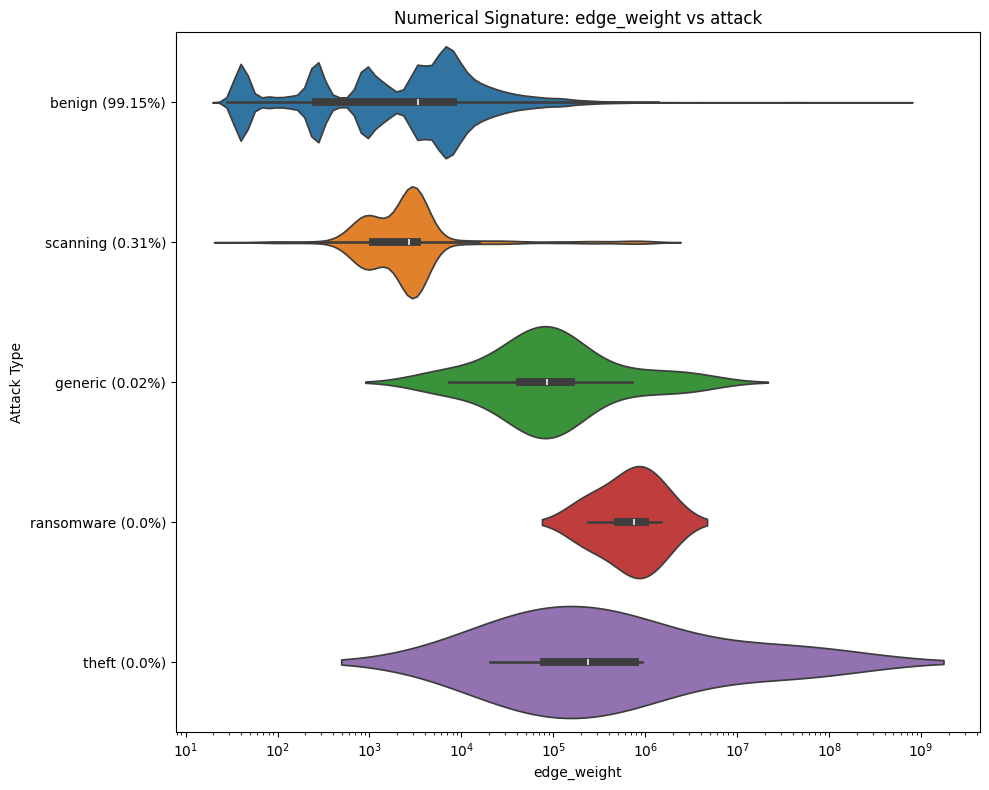

edge_weight has MINIMAL ASSOCATION with attack!


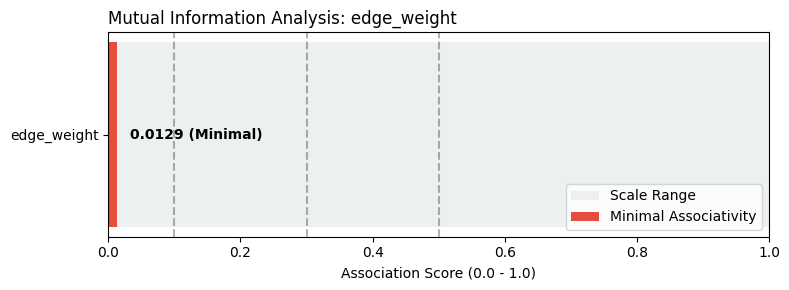

In [9]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'edge_weight')

---
##### Explore is_star_graph

- [Back to Table of Contents](#table-of-contents)

VERDICT: 

MISC: 
- 

is_star_graph IS NOT statistically significant with attack!
Statistic: 1.6554
P-Val: 1.0000
P-Threshold: 0.0500


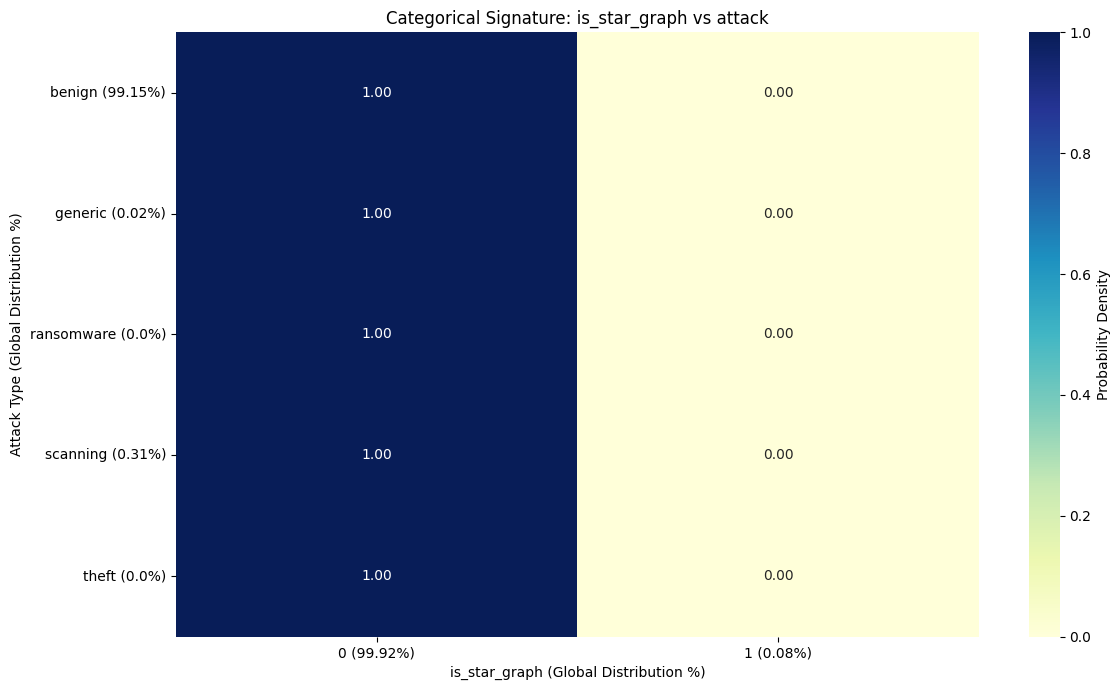

is_star_graph has MINIMAL ASSOCATION with attack!


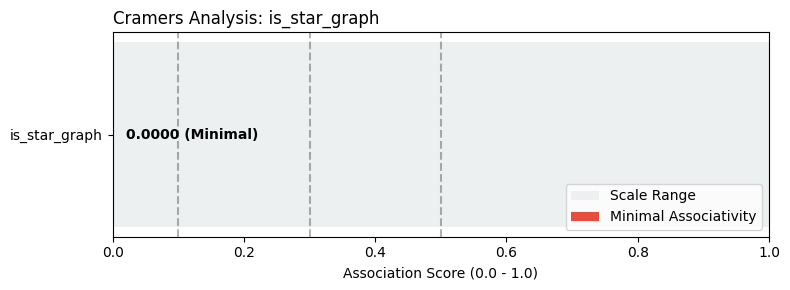

In [10]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'is_star_graph', is_object_feature=True)

---
##### Explore is_chain_graph

- [Back to Table of Contents](#table-of-contents)

VERDICT: 

MISC: 
- 

is_chain_graph IS NOT statistically significant with attack!
Statistic: 1.6554
P-Val: 1.0000
P-Threshold: 0.0500


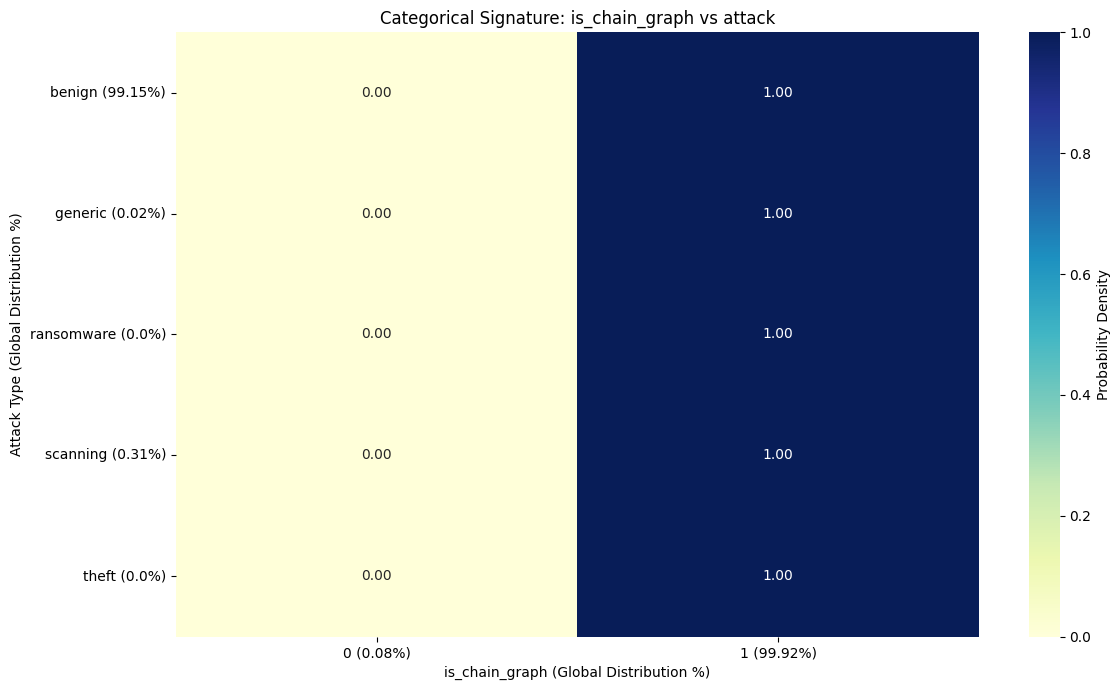

is_chain_graph has MINIMAL ASSOCATION with attack!


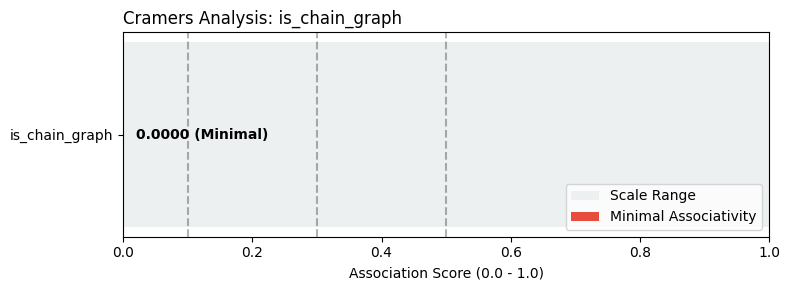

In [11]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'is_chain_graph', is_object_feature=True)

---
##### Explore is_bridge_link

- [Back to Table of Contents](#table-of-contents)

VERDICT: 

MISC: 
- 

is_bridge_link IS statistically significant with attack!
Statistic: 236.7071
P-Val: 0.0000
P-Threshold: 0.0500


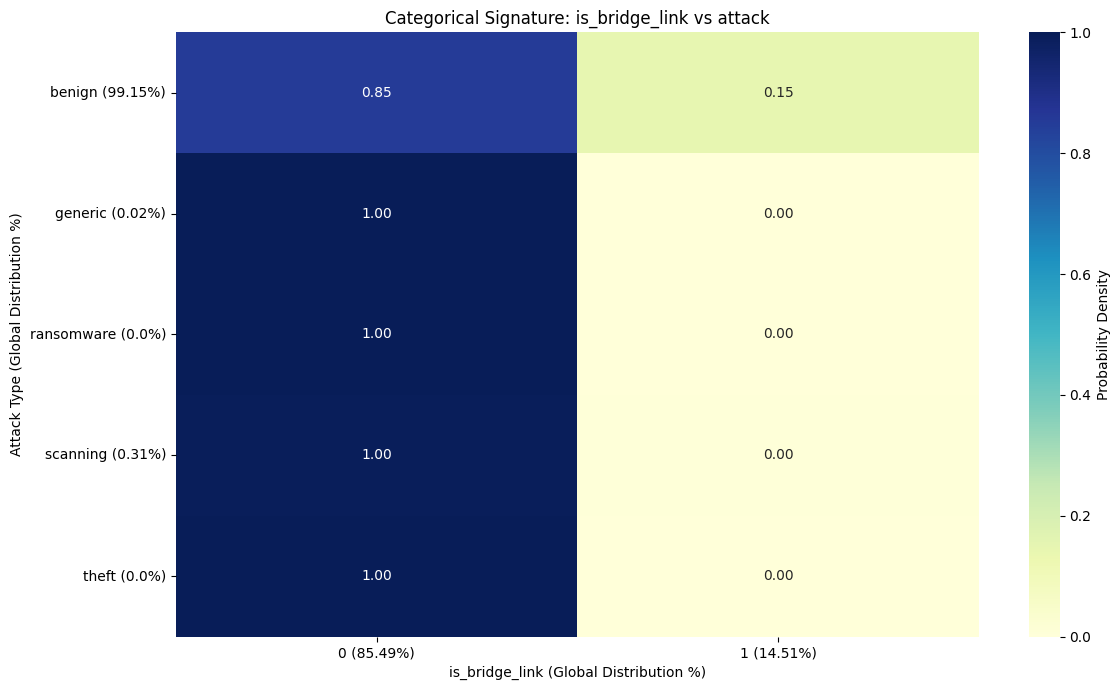

is_bridge_link has MINIMAL ASSOCATION with attack!


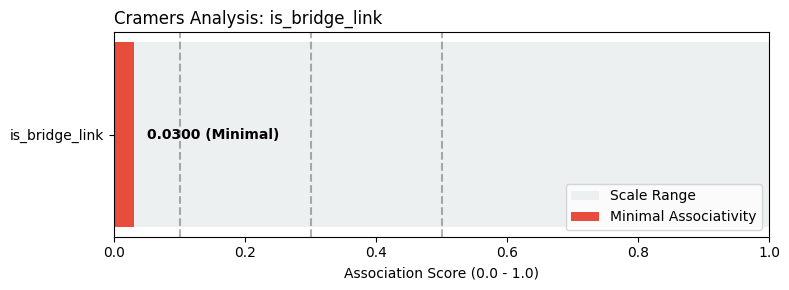

In [13]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'is_bridge_link', is_object_feature=True)

---
##### Explore graph_id

- [Back to Table of Contents](#table-of-contents)

VERDICT: 

MISC: 
- 

graph_id IS statistically significant with attack!
Statistic: 157012.1764
P-Val: 0.0000
P-Threshold: 0.0500


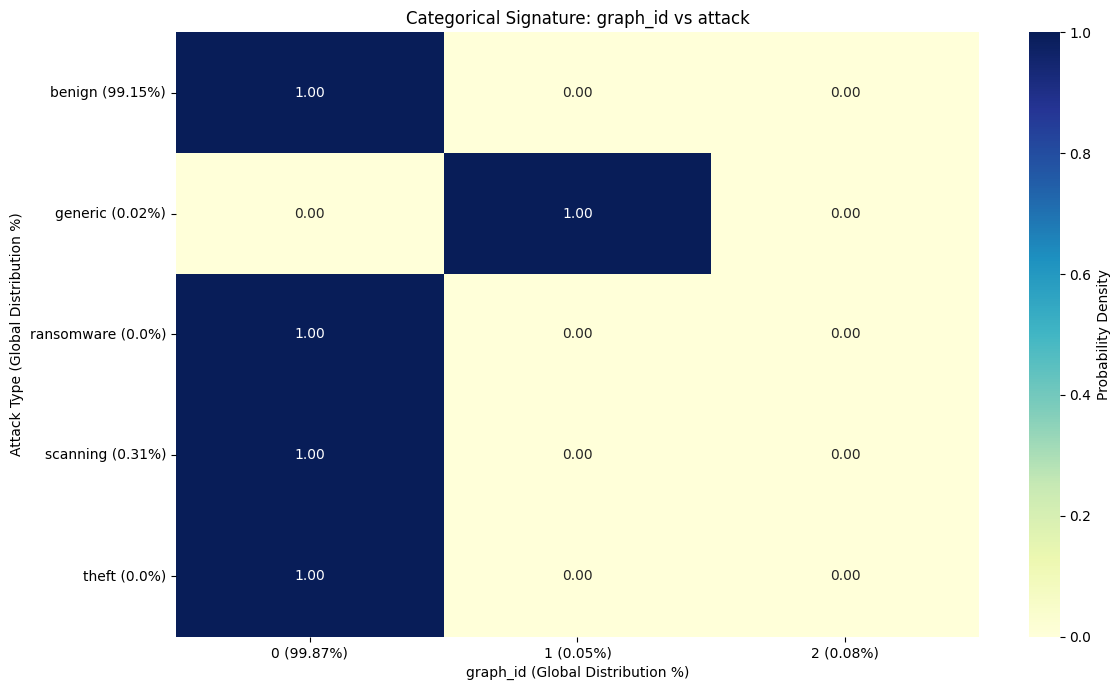

graph_id has HIGH ASSOCIATION with attack!


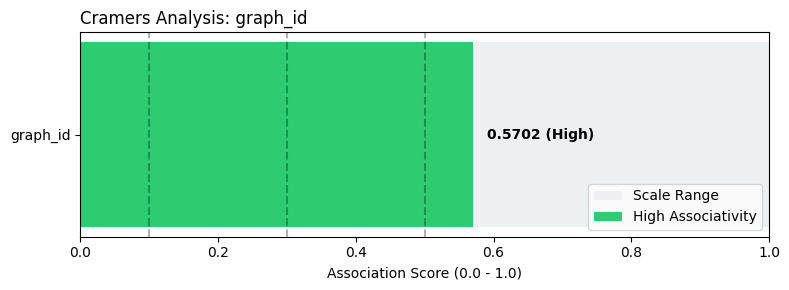

In [14]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'graph_id', is_object_feature=True)

---
##### Explore baseline_edge_weight_ratio

- [Back to Table of Contents](#table-of-contents)

VERDICT: 

MISC: 
- 

baseline_edge_weight_ratio IS statistically significant with attack!
Statistic: 1354.2759
P-Val: 0.0000
P-Threshold: 0.0500



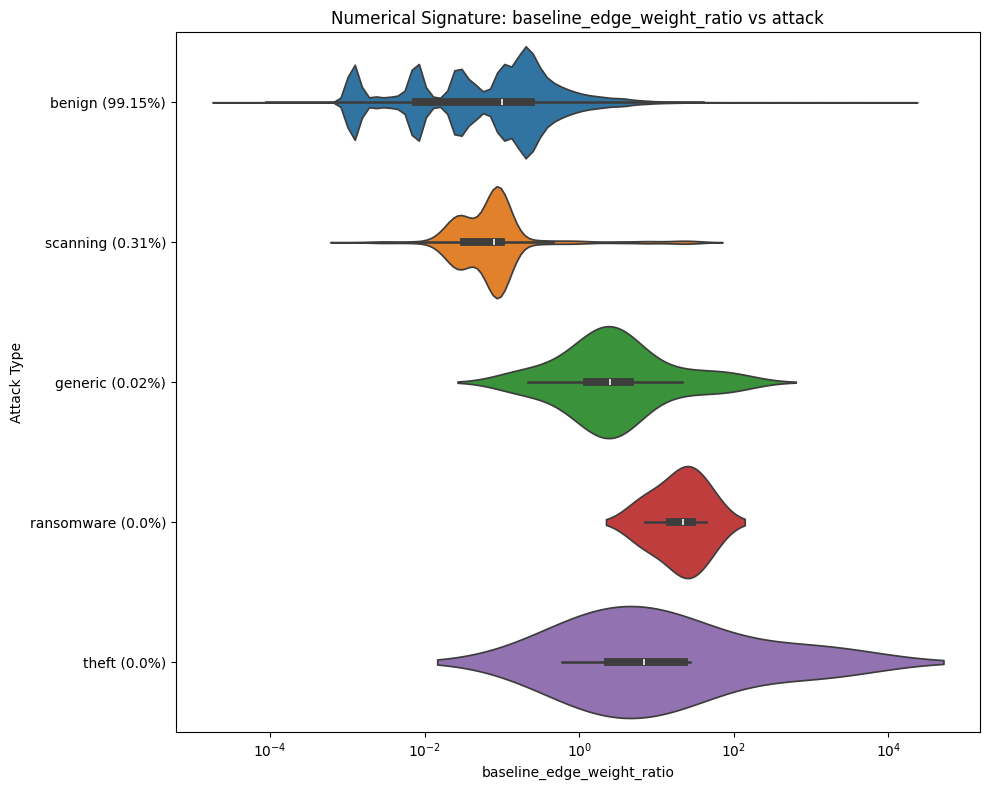

baseline_edge_weight_ratio has MINIMAL ASSOCATION with attack!


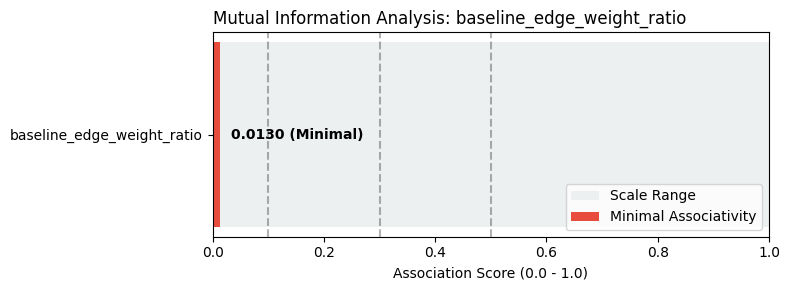

In [15]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'baseline_edge_weight_ratio')

---
##### Explore baseline_edge_weight_zscore

- [Back to Table of Contents](#table-of-contents)

VERDICT: 

MISC: 
- 

baseline_edge_weight_zscore IS statistically significant with attack!
Statistic: 1353.4480
P-Val: 0.0000
P-Threshold: 0.0500



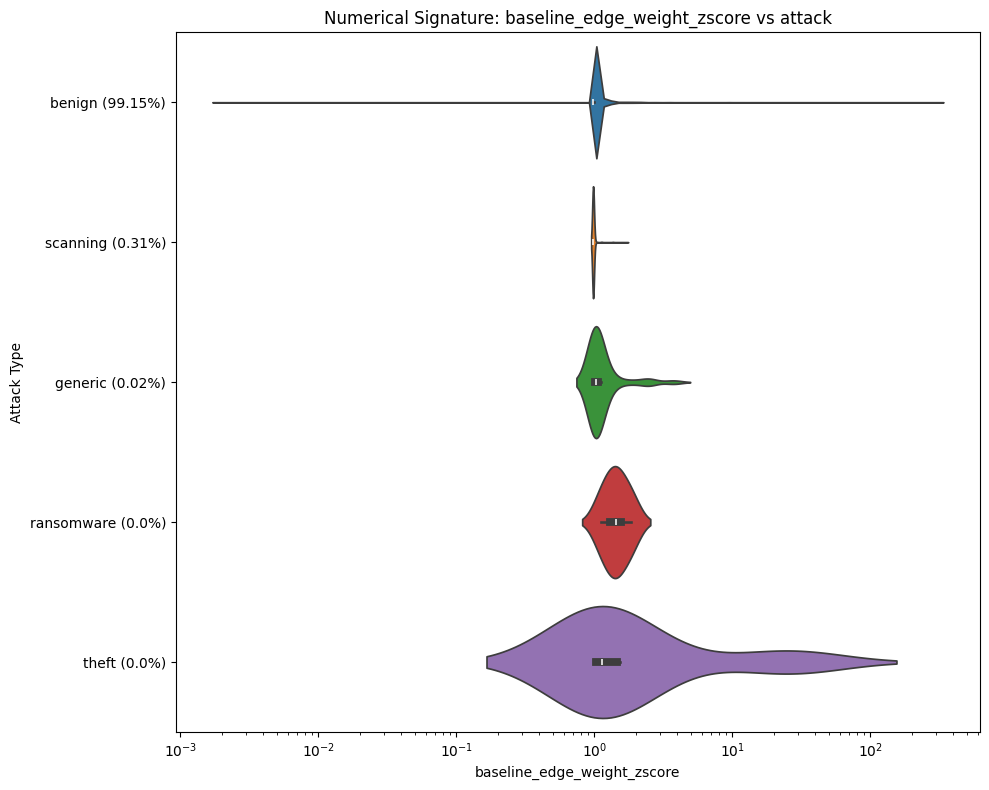

baseline_edge_weight_zscore has MINIMAL ASSOCATION with attack!


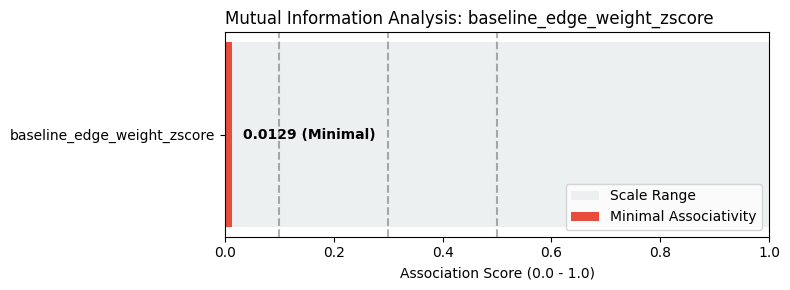

In [16]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'baseline_edge_weight_zscore')

---
##### Explore eigen_1

- [Back to Table of Contents](#table-of-contents)

VERDICT: 

MISC: 
- 

eigen_1 IS statistically significant with attack!
Statistic: 157012.1764
P-Val: 0.0000
P-Threshold: 0.0500


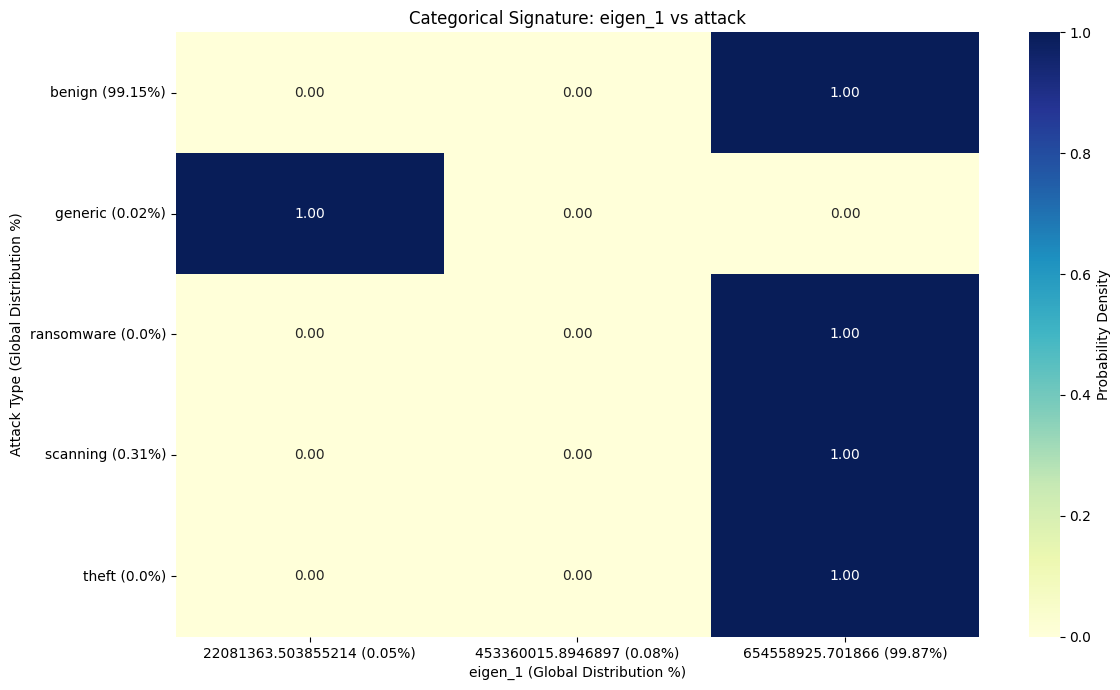

eigen_1 has HIGH ASSOCIATION with attack!


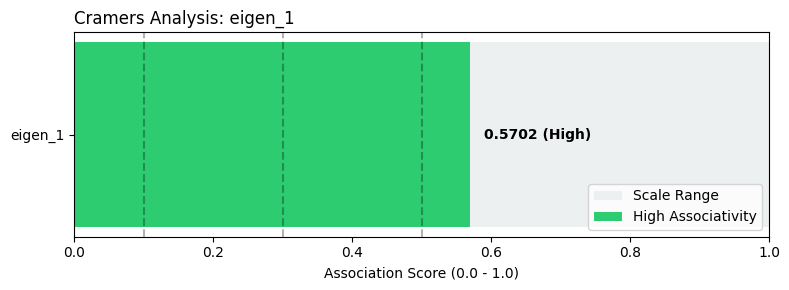

In [17]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'eigen_1', is_object_feature=True)

---
##### Explore eigen_2

- [Back to Table of Contents](#table-of-contents)

VERDICT: 

MISC: 
- 

eigen_2 IS statistically significant with attack!
Statistic: 157012.1764
P-Val: 0.0000
P-Threshold: 0.0500


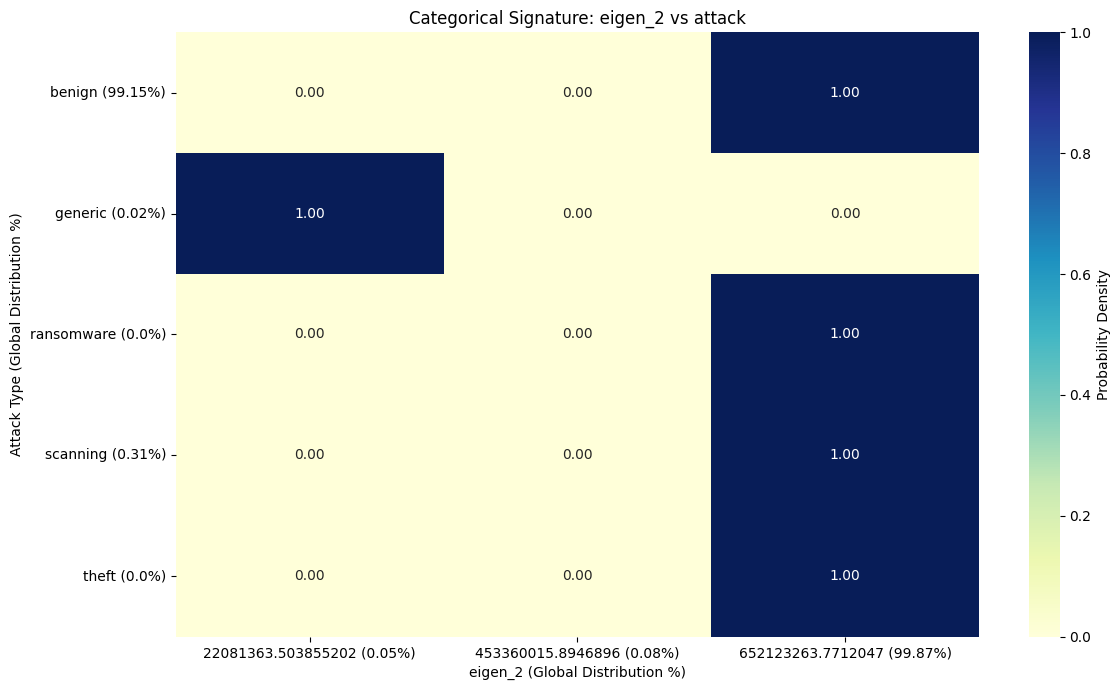

eigen_2 has HIGH ASSOCIATION with attack!


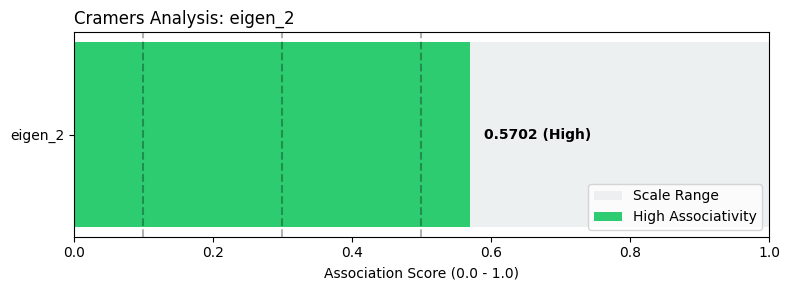

In [18]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'eigen_2', is_object_feature=True)

---
##### Explore v1_src

- [Back to Table of Contents](#table-of-contents)

VERDICT: 

MISC: 
- 

v1_src IS statistically significant with attack!
Statistic: 4081.0039
P-Val: 0.0000
P-Threshold: 0.0500



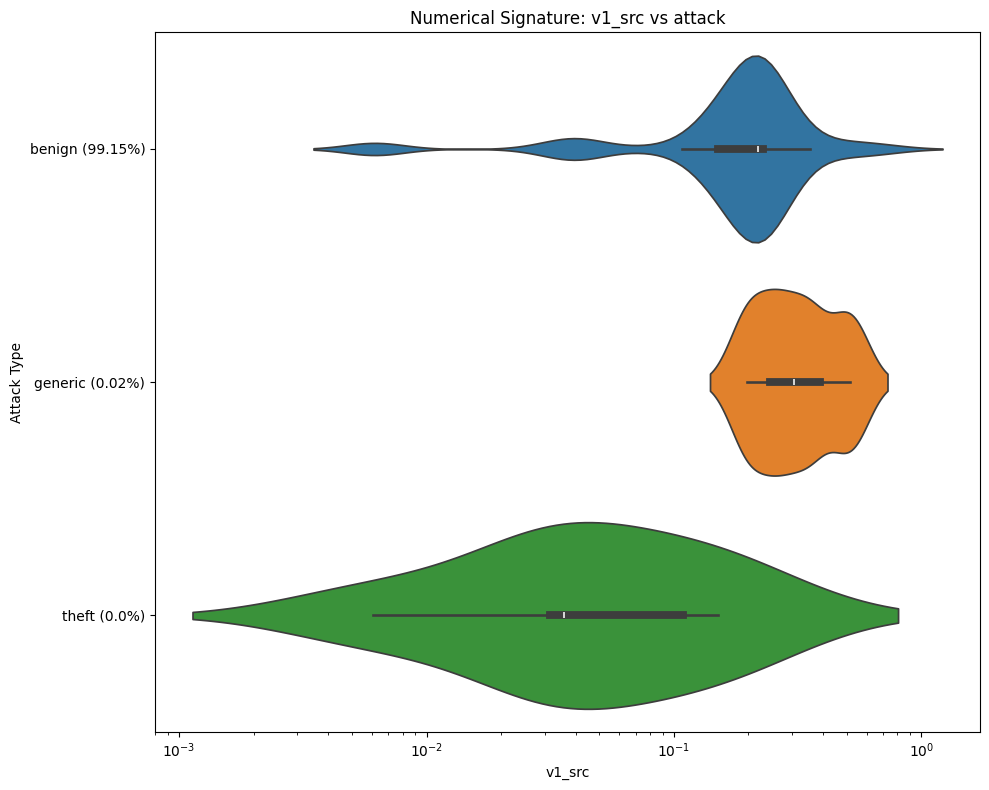

v1_src has MINIMAL ASSOCATION with attack!


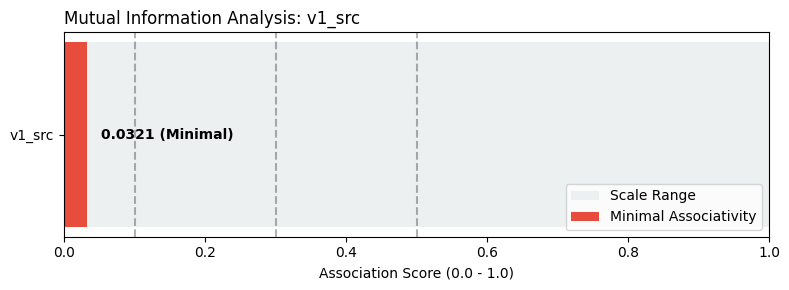

In [16]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'v1_src')

---
##### Explore v2_src

- [Back to Table of Contents](#table-of-contents)

VERDICT: 

MISC: 
- 

v2_src IS statistically significant with attack!
Statistic: 4086.2586
P-Val: 0.0000
P-Threshold: 0.0500



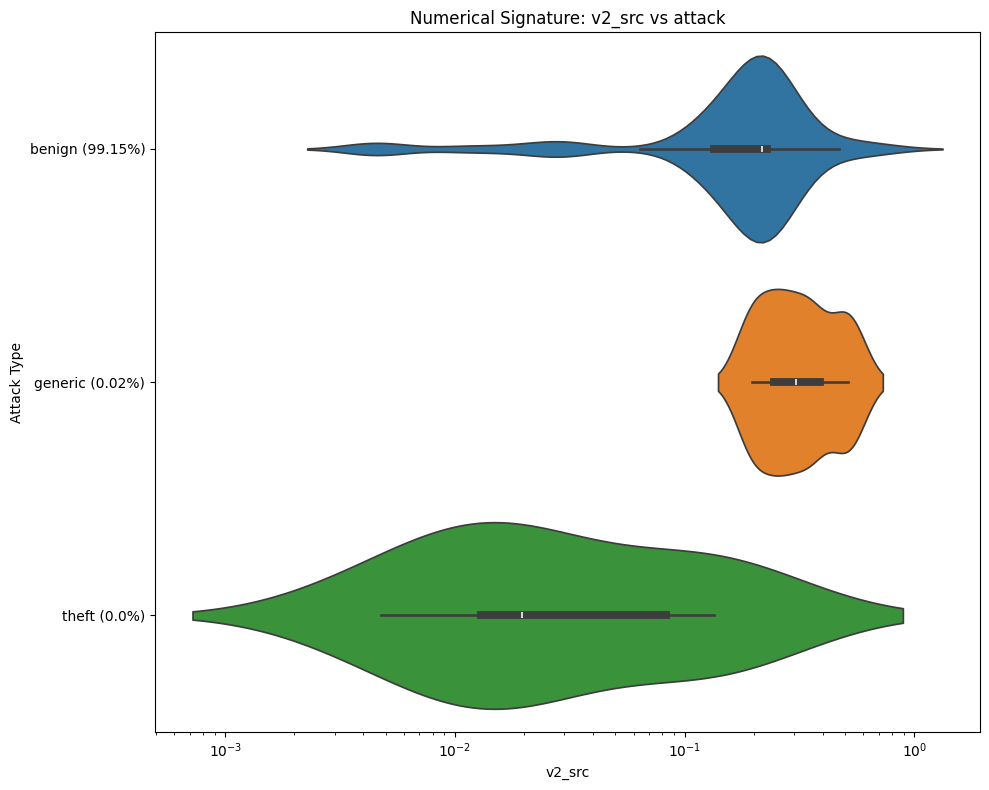

v2_src has MINIMAL ASSOCATION with attack!


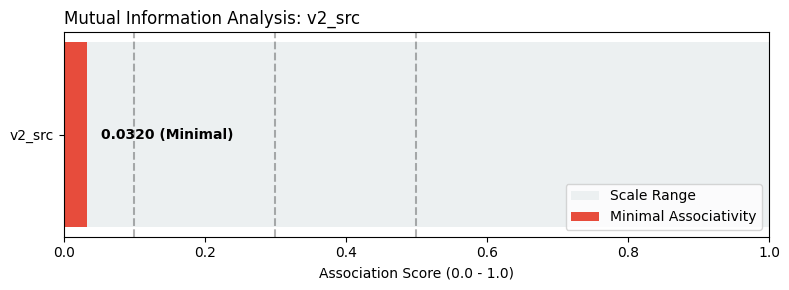

In [17]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'v2_src')

---
##### Explore src_pagerank

- [Back to Table of Contents](#table-of-contents)

VERDICT: 

MISC: 
- 

src_pagerank IS statistically significant with attack!
Statistic: 2826.6672
P-Val: 0.0000
P-Threshold: 0.0500



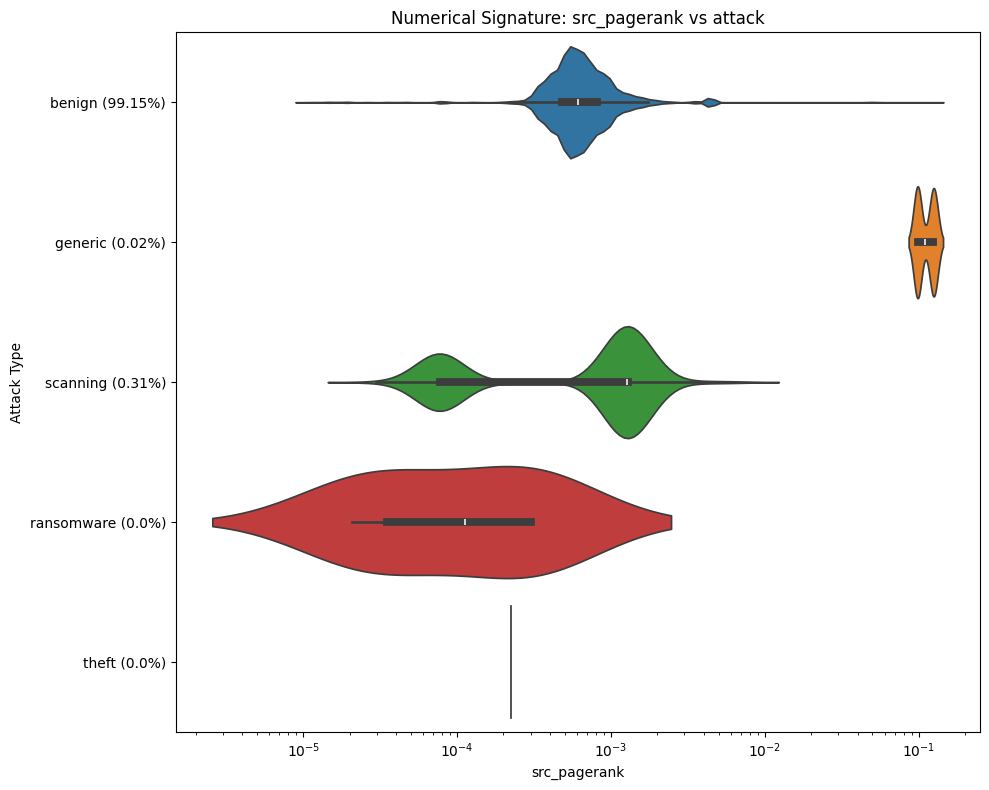

src_pagerank has MINIMAL ASSOCATION with attack!


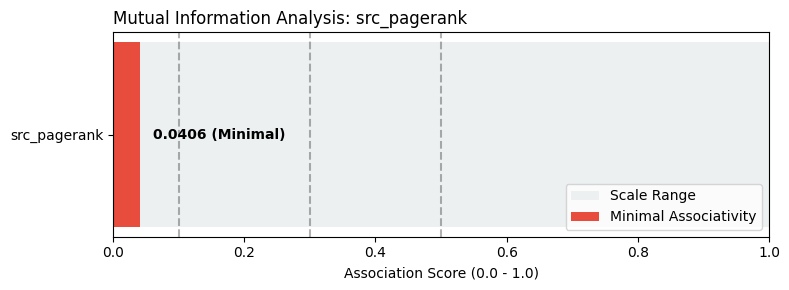

In [20]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'src_pagerank')

---
##### Explore dst_pagerank

- [Back to Table of Contents](#table-of-contents)

VERDICT: 

MISC: 
- 

dst_pagerank IS statistically significant with attack!
Statistic: 2398.6558
P-Val: 0.0000
P-Threshold: 0.0500



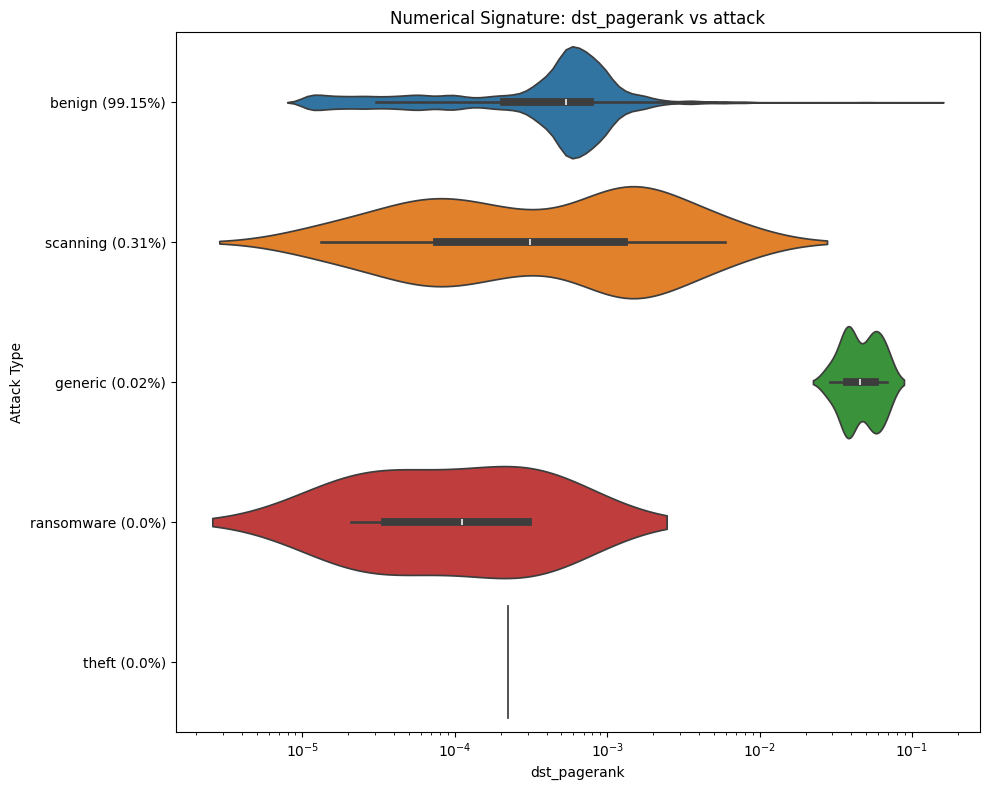

dst_pagerank has MINIMAL ASSOCATION with attack!


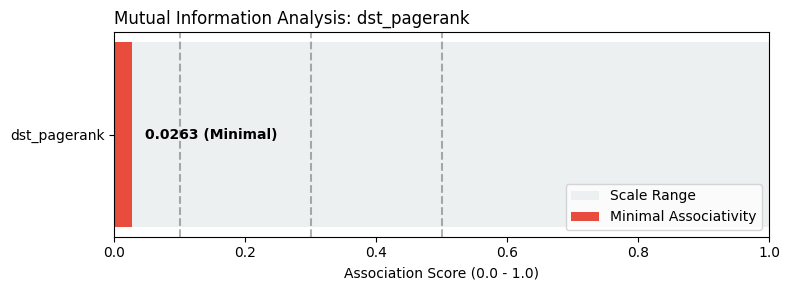

In [21]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'dst_pagerank')

---
##### Explore convergence_steps

- [Back to Table of Contents](#table-of-contents)

VERDICT: 

MISC: 
- 

convergence_steps IS statistically significant with attack!
Statistic: 157012.1764
P-Val: 0.0000
P-Threshold: 0.0500


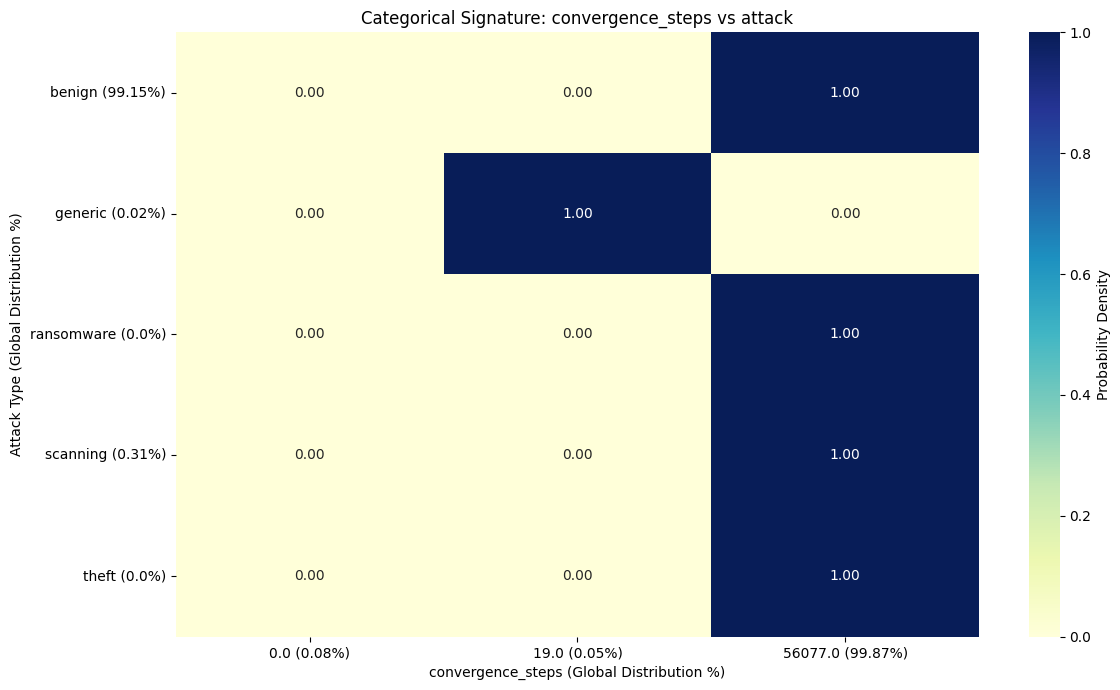

convergence_steps has HIGH ASSOCIATION with attack!


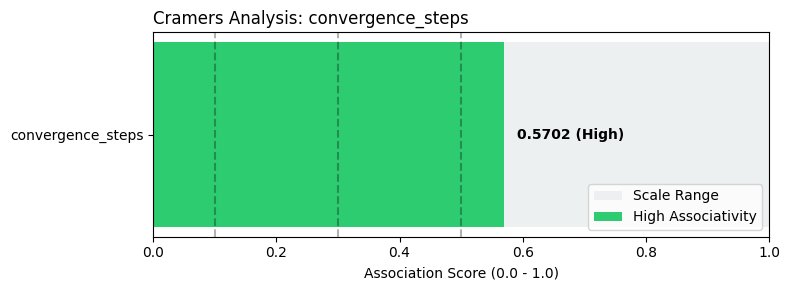

In [22]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'convergence_steps', is_object_feature=True)

---
##### Explore spectral_gap

- [Back to Table of Contents](#table-of-contents)

VERDICT: 

MISC: 
- 

spectral_gap IS statistically significant with attack!
Statistic: 157012.1764
P-Val: 0.0000
P-Threshold: 0.0500


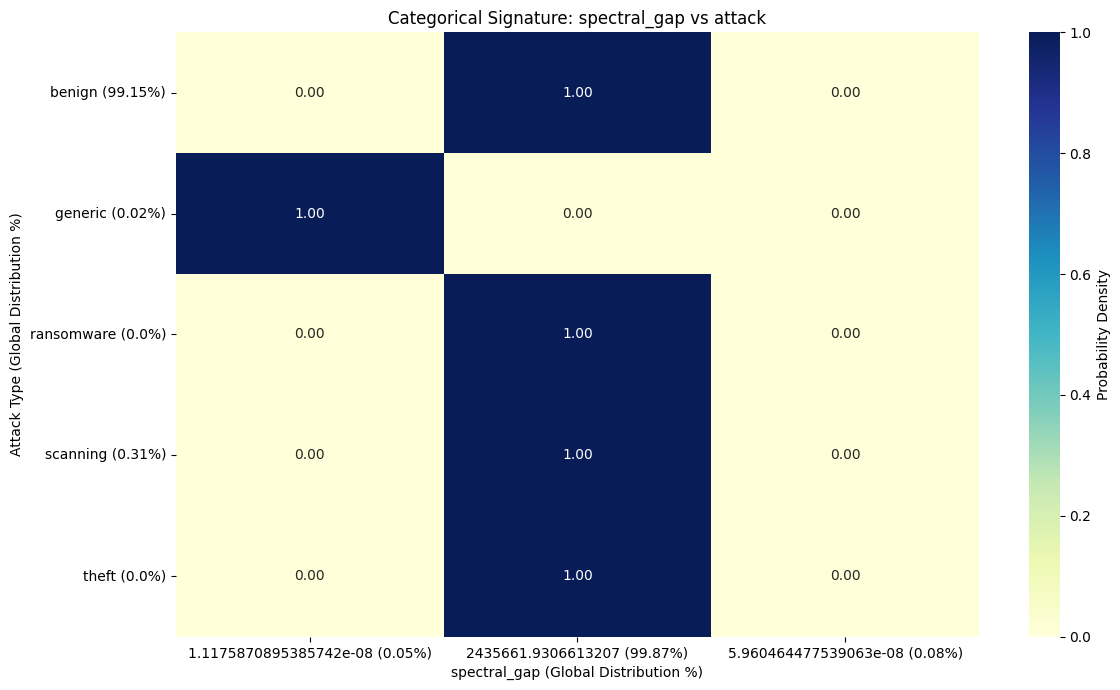

spectral_gap has HIGH ASSOCIATION with attack!


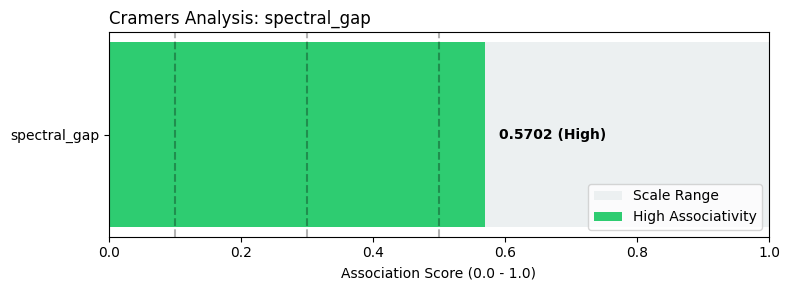

In [23]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'spectral_gap', is_object_feature=True)

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Final Data Dictionary

- [Back to Table of Contents](#table-of-contents)

</div>